In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [194]:
df = pd.read_csv('./data/single_dataset.csv')
df.head(10)

,area,price
0,513,127753
1,516,103001
2,518,168105
3,524,124119
4,534,176296
5,544,139585
6,544,122826
7,548,136833
8,554,90938
9,555,146701


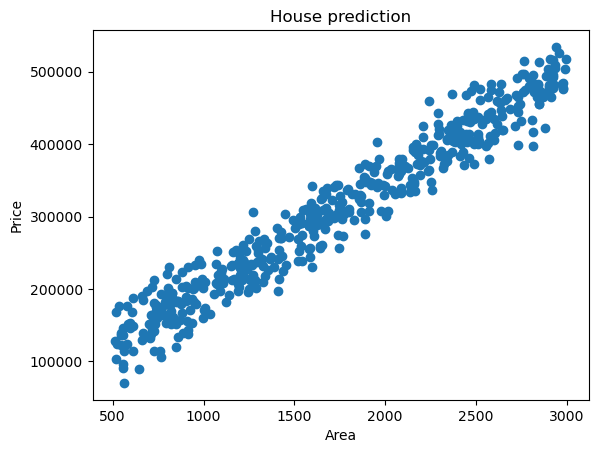

In [195]:
plt.scatter(df["area"], df["price"])

plt.xlabel("Area")
plt.ylabel("Price")

plt.title("House prediction")

plt.show()

In [196]:
# Chia dữ liệu thành train set và test set
x = df['area']
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

In [197]:
# Khởi tạo w,b để chuẩn bị cho gradient descent
w = 0
b = 0

df['prediction'] =  w * df['area'] + b

def calculate_MSE(df):
    squared_error = (df['prediction'] - df['price'])**2
    return squared_error.sum() / len(df)


In [198]:
def calculate_derivative_w(df):
    error = df["prediction"] - df["price"]
    return (2 / len(df)) * (error * df["area"]).sum()


def calculate_derivative_b(df):
    error = df["prediction"] - df["price"]
    return (2 / len(df)) * error.sum()

In [199]:
w = 0
b = 0
learning_rate = 1e-7

# Prediction
df["prediction"] = w * df["area"] + b

# Loss
mse = calculate_MSE(df)

# Gradient
dw = calculate_derivative_w(df)
db = calculate_derivative_b(df)


print("Weight: ", w)
print("Bias: ", b)

Weight:  0
Bias:  0


In [200]:
previous_loss = float("inf")
loss_history = []
for epoch in range(10000):
    df["prediction"] = w * df["area"] + b

    loss = calculate_MSE(df)

    dw = calculate_derivative_w(df)
    db = calculate_derivative_b(df)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if abs(previous_loss - loss) < 1e-6:
        break

    previous_loss = loss
    loss_history.append(loss)

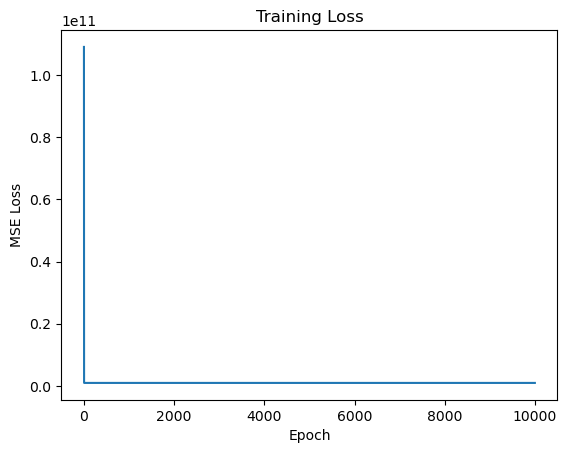

In [201]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.show()

In [202]:
print("w:", w)
print("b: ", b)
print("learning rate: ",  learning_rate)



w: 174.06401181511907
b:  13.712627186247513
learning rate:  1e-07


In [203]:
print("area min: ",df['area'].min())
print("area max: ",df['area'].max())
print("price min: ", df["price"].min())
print("price max: ", df["price"].max())

area min:  513
area max:  2996
price min:  70181
price max:  534217


In [204]:
w = 0
b = 0

learning_rate = 1e-7
max_epochs = 10000

loss_history = []

# Loss_0: trước khi update
df["prediction"] = w * df["area"] + b
loss_history.append(calculate_MSE(df))


for epoch in range(1, max_epochs + 1):

    # Gradient tại w, b hiện tại
    dw = calculate_derivative_w(df)
    db = calculate_derivative_b(df)

    # Update w, b
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Prediction mới sau khi update
    df["prediction"] = w * df["area"] + b

    # Loss mới
    loss = calculate_MSE(df)

    loss_history.append(loss)

In [205]:
print("Loss_0 =", loss_history[0])
print("Loss_10 =", loss_history[10])
print("Loss_100 =", loss_history[100])
print("Loss_1000 =", loss_history[1000])

print("Loss_final =", loss_history[-1])
print("w_final =", w)
print("b_final =", b)

Loss_0 = 109016467345.622
Loss_10 = 974651312.6300974
Loss_100 = 974649639.2891074
Loss_1000 = 974632921.7418863
Loss_final = 974465793.6377318
w_final = 174.06401181511907
b_final = 13.712627186247513


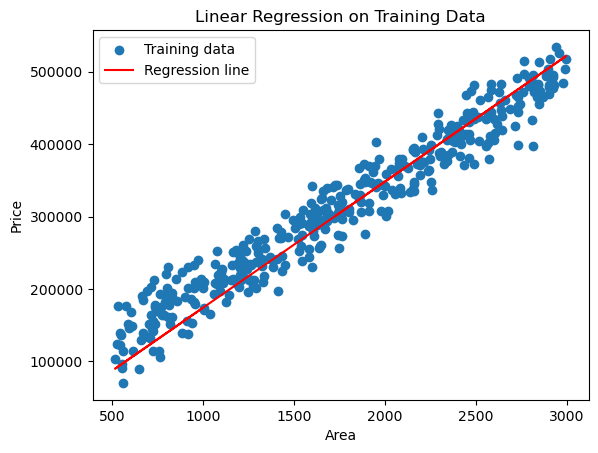

In [209]:
import matplotlib.pyplot as plt

w = 174.064
b = 13.713

y_pred_train = w * x_train + b

plt.scatter(x_train, y_train, label="Training data")
plt.plot(x_train, y_pred_train, color="red", label="Regression line")

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression on Training Data")
plt.legend()

plt.show()